In [ ]:
# The objective of this experiment is to build and evaluate an Artificial Neural Network (ANN) model to predict housing prices using the Boston Housing dataset.
# The model uses multiple input features related to housing characteristics and applies deep learning techniques to learn the relationship between these features
# and the target variable (house price).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping


In [ ]:
data = pd.read_csv("BostonHousing.csv")

print("Dataset Shape:", data.shape)


Dataset Shape: (506, 14)


In [ ]:
X = data.iloc[:, 0:11]
y = data.iloc[:, 13]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (506, 11)
y shape: (506,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

model.add(Dense(100, activation='relu', input_shape=(11,)))
model.add(Dense(70, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 622.8480 - mae: 23.1911 - val_loss: 530.8439 - val_mae: 21.4988
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 548.2053 - mae: 21.6507 - val_loss: 482.0341 - val_mae: 20.3849
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 540.3644 - mae: 21.1713 - val_loss: 423.9790 - val_mae: 18.9880
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 427.0421 - mae: 18.5803 - val_loss: 350.4313 - val_mae: 17.0786
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 364.3235 - mae: 16.9794 - val_loss: 259.7693 - val_mae: 14.4017
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 259.6667 - mae: 13.9086 - val_loss: 168.0312 - val_mae: 11.0967
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 159.5155 - mae: 10.3275 - val_loss: 94.1535 - val_mae: 7.6174
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 104.8536 - mae: 8.0147 - val_loss: 55.0088 - val_mae: 5.3507
Epoch 9/200


In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 11.7700 - mae: 2.3514

Test Loss (MSE): 17.554059982299805
Test MAE: 2.4801926612854004


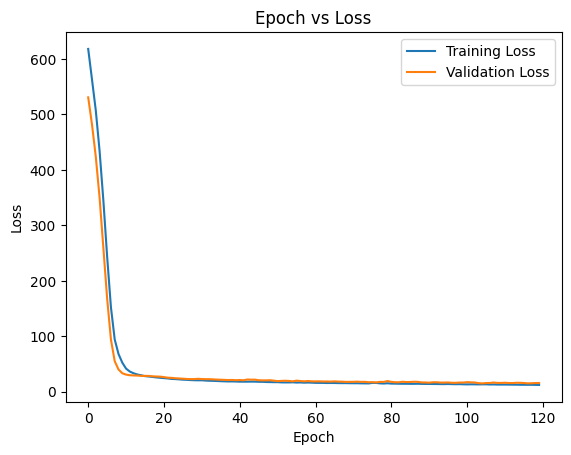

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()


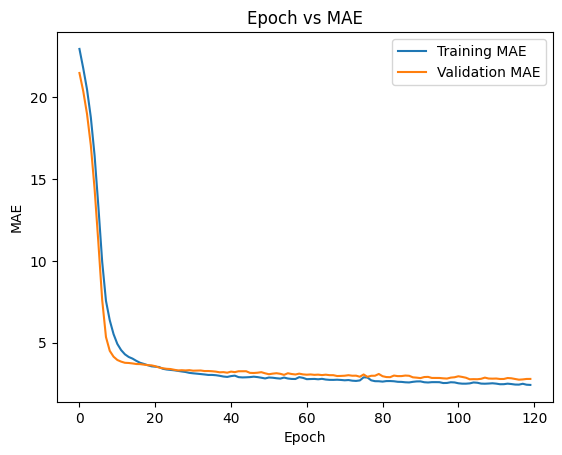

In [ ]:
plt.figure()
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Epoch vs MAE")
plt.legend(["Training MAE", "Validation MAE"])
plt.show()